In [1]:
import starry
import starry_process
import theano
theano.config.gcc__cxxflags += " -fexceptions"
theano.config.on_opt_error = "raise"
theano.tensor.opt.constant_folding
theano.graph.opt.EquilibriumOptimizer
import numpy as np
import matplotlib.pyplot as plt

WARNING (theano.link.c.cmodule): install mkl with `conda install mkl-service`: No module named 'mkl'
The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.


In [25]:
from starry_process.size import SizeIntegral
from starry_process.latitude import LatitudeIntegral
from starry_process.longitude import LongitudeIntegral
from starry_process.ops import LatitudeIntegralOp
from starry_process.wigner import R
from starry_process.defaults import defaults
import numpy as np
from scipy.integrate import quad
from scipy.stats import beta as Beta
from tqdm import tqdm
from theano.configparser import change_flags
from starry_process.compat import theano, tt

In [10]:
from starry_process.defaults import defaults

log_alpha_max = defaults["log_alpha_max"]
log_beta_max  = defaults["log_beta_max"]

In [11]:
def alpha_beta_to_ab(alpha, beta,
                    log_alpha_max=10.0,
                    log_beta_max=10.0):

    alpha = np.asarray(alpha)
    beta  = np.asarray(beta)

    a = np.log(alpha) / log_alpha_max
    b = (np.log(beta) - np.log(0.5)) / (log_beta_max - np.log(0.5))

    return a, b

In [163]:
alpha = 5*np.sqrt(3)
beta = 10-alpha
lmax = 5

r = np.rad2deg(0.1)
c = 0.5

a, b = alpha_beta_to_ab(alpha, beta)

In [164]:
map = starry.Map(ydeg = lmax)
map.spot(radius=r, contrast=c)

Pre-computing some matrices... Done.


Compiling `render`... Done.


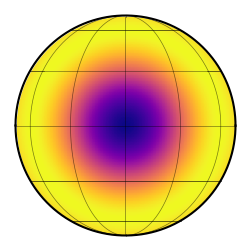

In [165]:
map.show()

In [166]:
er = np.array([
    0.99657637,
    0.0, -0.00436468, 0.0,
    0.0, 0.0, -0.00531181, 0.0, 0.0,
    0.0, 0.0, 0.0, -0.00344001, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, -0.00395098, 0.0, 0.0, 0.0, 0.0,
    0.0, 0.0, 0.0, 0.0, 0.0, -0.00175227, 0.0, 0.0, 0.0, 0.0, 0.0
])

In [228]:
N = (lmax + 1)**2
Er = np.zeros((N, N))

for l in range(lmax + 1):
    for lp in range(lmax + 1):
        Er[l**2 + l, lp**2 + lp] = er[l**2 + l] * er[lp**2 + lp]

In [249]:
class FixedER:
    def __init__(self, er, lmax):
        self.er = np.asarray(er, dtype=float)
        self.lmax = lmax
        self.N = (lmax + 1)**2

        self.eigEr = np.zeros((self.N, 1), dtype=float)

        for l in range(lmax + 1):
            i = l**2 + l  
            self.eigEr[i, 0] = self.er[i]

    def first_moment(self):
        return self.er

    def second_moment(self):
        return self.eigEr

In [ ]:
S = FixedER(er, lmax)

I_lat = LatitudeIntegral(a, b, child=S, ydeg=lmax)

ephi = I_lat.first_moment().eval()

eigEphi = I_lat.second_moment().eval()
Ephi = eigEphi @ eigEphi.T

In [253]:
sp = starry_process.StarryProcess(r=r, c=c,ydeg=lmax)

In [254]:
ephi

array([ 9.96576370e-01,  0.00000000e+00, -3.77992376e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.40392283e-03,  0.00000000e+00,
        1.10151917e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.34178268e-03,  0.00000000e+00,  1.26828846e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.88361147e-04,  0.00000000e+00,  1.86043549e-03,  0.00000000e+00,
       -2.48092686e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.83530673e-05,  0.00000000e+00,
        8.63997019e-04,  0.00000000e+00, -2.44006693e-04,  0.00000000e+00])

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


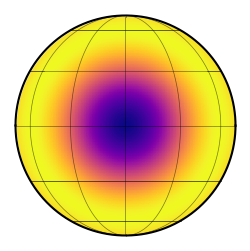

In [255]:
map[:,:] = er
map.show()

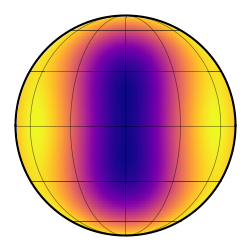

In [256]:
map[:,:] = ephi
map.show()

In [257]:
ephi

array([ 9.96576370e-01,  0.00000000e+00, -3.77992376e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.40392283e-03,  0.00000000e+00,
        1.10151917e-03,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -1.34178268e-03,  0.00000000e+00,  1.26828846e-03,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
       -6.88361147e-04,  0.00000000e+00,  1.86043549e-03,  0.00000000e+00,
       -2.48092686e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -4.83530673e-05,  0.00000000e+00,
        8.63997019e-04,  0.00000000e+00, -2.44006693e-04,  0.00000000e+00])

In [ ]:
I_long = LongitudeIntegral(child=I_lat, ydeg=lmax)

In [ ]:
elambda = I_long.first_moment().eval()

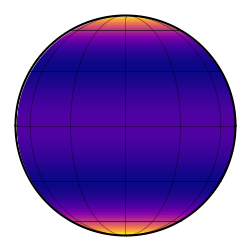

In [260]:
map[:,:] = elambda
map.show()

In [261]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

In [262]:
np.log(Ephi.conj().T)

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_52261/2742142832.py:1: RuntimeWarning: divide by zero encountered in log
  np.log(Ephi.conj().T)
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_52261/2742142832.py:1: RuntimeWarning: invalid value encountered in log
  np.log(Ephi.conj().T)


array([[-6.85900806e-03,             nan,             nan, ...,
                   -inf,             nan,            -inf],
       [            nan, -1.22978221e+01,             nan, ...,
                   -inf, -4.51317196e+01,            -inf],
       [            nan,             nan, -1.11421372e+01, ...,
                   -inf, -1.40290925e+01,            -inf],
       ...,
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf],
       [            nan, -4.51317196e+01, -1.40290925e+01, ...,
                   -inf, -1.58845749e+01,            -inf],
       [           -inf,            -inf,            -inf, ...,
                   -inf,            -inf,            -inf]])

/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_52261/1566870390.py:1: RuntimeWarning: divide by zero encountered in log
  plt.imshow(np.log(Ephi.conj().T))
/var/folders/6b/q0ls5s7570d8s04fbvw5gmxw0000gn/T/ipykernel_52261/1566870390.py:1: RuntimeWarning: invalid value encountered in log
  plt.imshow(np.log(Ephi.conj().T))


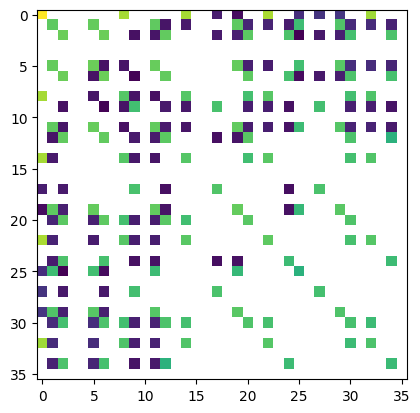

In [263]:
plt.imshow(np.log(Ephi.conj().T))

In [264]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

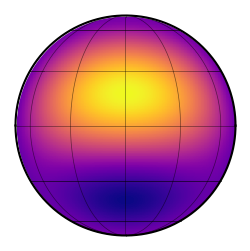

In [265]:
map[:,:] = np.diag(Ephi)
map.show()

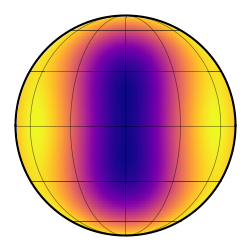

In [267]:
map[:,:] = Ephi[:,0]
map.show()

In [268]:
Ephi

array([[ 9.93164461e-01, -2.70617036e-19, -3.76698270e-03, ...,
         0.00000000e+00, -2.43171304e-04,  0.00000000e+00],
       [-2.70617036e-19,  4.56166842e-06, -8.34159675e-21, ...,
         0.00000000e+00,  2.50924586e-20,  0.00000000e+00],
       [-3.76698270e-03, -8.34159675e-21,  1.44887631e-05, ...,
         0.00000000e+00,  8.07685973e-07,  0.00000000e+00],
       ...,
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
       [-2.43171304e-04,  2.50924586e-20,  8.07685973e-07, ...,
         0.00000000e+00,  1.26303909e-07,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00]])

In [271]:
I_lon = LongitudeIntegral(child=I_lat, ydeg=lmax)

elambda = I_lon.first_moment().eval()

eigElambda = I_lon.second_moment().eval()
Elambda = eigElambda @ eigElambda.T

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


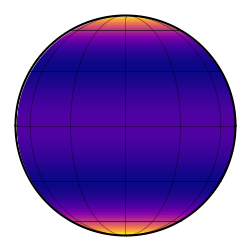

In [272]:
map[:,:] = elambda
map.show()

In [273]:
elambda

array([ 9.96576370e-01,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -3.74008914e-04,  0.00000000e+00,
       -6.47802441e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        2.24404728e-04,  0.00000000e+00,  3.34522818e-04,  0.00000000e+00,
        4.42532092e-04,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00, -1.60250277e-20,  0.00000000e+00,
       -2.73293957e-20,  0.00000000e+00,  6.83232695e-21,  0.00000000e+00])

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


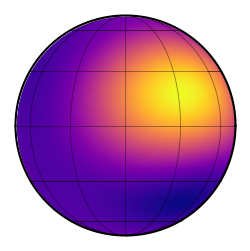

In [274]:
map[:,:] = np.diag(Elambda)
map.show()

In [275]:
Elambda

array([[ 9.93164461e-01, -2.15387047e-19,  6.71694166e-19, ...,
         2.63695507e-20,  4.59187787e-19,  1.05120971e-20],
       [-2.15387047e-19,  4.56166842e-06, -1.90164089e-21, ...,
        -1.01476543e-21, -1.45467098e-22, -3.57342503e-21],
       [ 6.71694166e-19, -1.90164089e-21,  7.24438154e-06, ...,
         6.33993194e-20, -4.27780804e-07,  1.09890481e-20],
       ...,
       [ 2.63695507e-20, -1.01476543e-21,  6.33993194e-20, ...,
         2.58341447e-07,  3.49235306e-20, -2.19461423e-08],
       [ 4.59187787e-19, -1.45467098e-22, -4.27780804e-07, ...,
         3.49235306e-20,  2.47653452e-07,  2.79307668e-21],
       [ 1.05120971e-20, -3.57342503e-21,  1.09890481e-20, ...,
        -2.19461423e-08,  2.79307668e-21,  2.18209612e-07]])

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


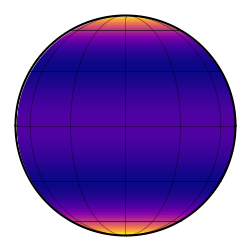

In [276]:
map[:,:] = Elambda[:,0]
map.show()

In [277]:
variance_matrix = Elambda - elambda[:, None] * elambda[None, :]

/Users/sabina/miniconda3/envs/starry-env/lib/python3.9/site-packages/numpy/core/_methods.py:48: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


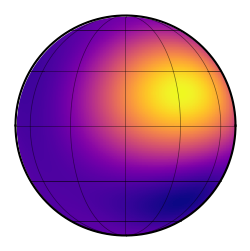

In [279]:
map[:,:] = np.diag(variance_matrix)
map.show()